In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

In [78]:
# getting the values from the dataeset
df = pd.read_csv("/content/drive/MyDrive/SDGP/ML/Dataset - Long beans.csv", encoding="utf-8")

In [79]:
# printing the first 5 values
df.head()

,year,month,producer_price,wholesale_price,retail_price,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt,inflation_percentage_ncip_food,inflation_percentage_ncip_all_items,inflation_percentage_ncip_non_food,National Production MT
0,2014,January,22.37,29.99,93.59,17116.88000,45789.28000,14198.75000,18921.70000,33139.11000,0.0,46.2,62.7,86.3,1365.7,27.8,0.3,3.1,5.2,4345.7
1,2014,February,28.77,30.29,91.75,17082.64624,45835.06928,14127.75625,18978.46510,33105.97089,0.0,46.2,62.7,86.3,1365.7,27.8,-0.5,-0.1,0.3,4345.7
2,2014,March,29.89,27.78,88.47,17031.39830,45880.90435,14170.13952,18997.44357,33172.18283,0.0,46.2,62.7,86.3,1365.7,27.8,0.3,0.2,0.1,4345.7
3,2014,April,33.26,36.83,85.06,17167.64949,45880.90435,14411.03189,19054.43590,33470.73248,12.8,23.5,32.0,67.2,158.0,133.3,1.7,0.9,0.3,3025.8
4,2014,May,48.12,62.59,119.51,17425.16423,45835.02344,14684.84150,19054.43590,33738.49834,12.8,23.5,32.0,67.2,158.0,133.3,1.9,0.8,0.0,3025.8


Renaming the columns to a more efficent progression.

In [80]:
# renaming columns for easy progression
df.rename(columns={
    'National Production MT' : 'national_production_mt'
}, inplace=True)
df.head()

,year,month,producer_price,wholesale_price,retail_price,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt,inflation_percentage_ncip_food,inflation_percentage_ncip_all_items,inflation_percentage_ncip_non_food,national_production_mt
0,2014,January,22.37,29.99,93.59,17116.88000,45789.28000,14198.75000,18921.70000,33139.11000,0.0,46.2,62.7,86.3,1365.7,27.8,0.3,3.1,5.2,4345.7
1,2014,February,28.77,30.29,91.75,17082.64624,45835.06928,14127.75625,18978.46510,33105.97089,0.0,46.2,62.7,86.3,1365.7,27.8,-0.5,-0.1,0.3,4345.7
2,2014,March,29.89,27.78,88.47,17031.39830,45880.90435,14170.13952,18997.44357,33172.18283,0.0,46.2,62.7,86.3,1365.7,27.8,0.3,0.2,0.1,4345.7
3,2014,April,33.26,36.83,85.06,17167.64949,45880.90435,14411.03189,19054.43590,33470.73248,12.8,23.5,32.0,67.2,158.0,133.3,1.7,0.9,0.3,3025.8
4,2014,May,48.12,62.59,119.51,17425.16423,45835.02344,14684.84150,19054.43590,33738.49834,12.8,23.5,32.0,67.2,158.0,133.3,1.9,0.8,0.0,3025.8


In [81]:
missing_values = df.isnull().sum()
print('Missing values')
print(missing_values)

Missing values
year                                   0
month                                  0
producer_price                         0
wholesale_price                        0
retail_price                           0
inflation_ccip_food                    0
inflation_ccip_non_food                0
inflation_ncip_food                    0
inflation_ncip_non_food                0
inflation_ncip_all_items               0
colombo_production_mt                  0
gampaha_production_mt                  0
kaluthara_production_mt                0
galle_production_mt                    0
hambantota_production_mt               0
matara_production_mt                   0
inflation_percentage_ncip_food         0
inflation_percentage_ncip_all_items    0
inflation_percentage_ncip_non_food     0
national_production_mt                 0
dtype: int64


In [82]:
def filling_missing_prices_with_mean(month, price):
  # selecting the rows of the april month
  filtered_df = df[df["month"] == month]

  # caluclating the mean of the producer price column
  price_mean = filtered_df[price].mean()
  print(price_mean)

  # replacing NaN values with the mean
  df.loc[df["month"] == month, price] = df.loc[df["month"] == month, price].fillna(price_mean)

  print(f"{price} of {month} filled with the mean")


In [83]:
df.describe()

,year,producer_price,wholesale_price,retail_price,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt,inflation_percentage_ncip_food,inflation_percentage_ncip_all_items,inflation_percentage_ncip_non_food,national_production_mt
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,2018.000000,74.957674,95.296690,169.542315,24838.380849,54802.082005,20021.720674,23388.695900,43344.563976,45.241667,113.213889,95.644444,110.500000,503.466667,134.863889,1.034259,0.898148,0.787037,5057.963889
std,2.594026,35.168081,49.383194,66.424212,8839.596970,10906.871709,6573.095917,4945.556906,11494.536733,26.194970,52.471104,40.211042,35.000238,305.159294,27.274689,2.909738,2.034974,1.669859,918.124342
min,2014.000000,22.370000,27.780000,85.060000,17031.398300,44694.656700,14127.756250,18844.597440,33105.970890,0.000000,23.500000,32.000000,36.000000,158.000000,27.800000,-6.100000,-3.500000,-1.200000,3025.800000
25%,2016.000000,48.975000,61.435000,127.312500,19596.896925,46939.352745,16133.027595,20116.328670,36304.129143,35.475000,67.700000,64.950000,93.575000,277.700000,127.000000,-0.525000,-0.100000,0.100000,4276.800000
50%,2018.000000,65.235000,82.280000,145.675000,22411.967760,52626.931945,17946.954940,22375.641730,40560.035445,42.800000,112.300000,95.000000,111.800000,409.000000,130.950000,0.850000,0.600000,0.300000,5243.300000
75%,2020.000000,95.395000,120.155000,191.760000,25816.404043,56672.533452,20613.306755,24187.304995,44773.021978,53.125000,147.575000,122.700000,126.175000,686.575000,147.700000,2.200000,1.300000,0.600000,5826.075000
max,2022.000000,185.620000,244.250000,371.020000,55286.468880,93869.281500,42108.762500,41350.671970,82834.318340,106.700000,239.300000,159.700000,197.300000,1365.700000,189.200000,14.200000,10.900000,8.600000,6514.000000


In [84]:
df.head()

,year,month,producer_price,wholesale_price,retail_price,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt,inflation_percentage_ncip_food,inflation_percentage_ncip_all_items,inflation_percentage_ncip_non_food,national_production_mt
0,2014,January,22.37,29.99,93.59,17116.88000,45789.28000,14198.75000,18921.70000,33139.11000,0.0,46.2,62.7,86.3,1365.7,27.8,0.3,3.1,5.2,4345.7
1,2014,February,28.77,30.29,91.75,17082.64624,45835.06928,14127.75625,18978.46510,33105.97089,0.0,46.2,62.7,86.3,1365.7,27.8,-0.5,-0.1,0.3,4345.7
2,2014,March,29.89,27.78,88.47,17031.39830,45880.90435,14170.13952,18997.44357,33172.18283,0.0,46.2,62.7,86.3,1365.7,27.8,0.3,0.2,0.1,4345.7
3,2014,April,33.26,36.83,85.06,17167.64949,45880.90435,14411.03189,19054.43590,33470.73248,12.8,23.5,32.0,67.2,158.0,133.3,1.7,0.9,0.3,3025.8
4,2014,May,48.12,62.59,119.51,17425.16423,45835.02344,14684.84150,19054.43590,33738.49834,12.8,23.5,32.0,67.2,158.0,133.3,1.9,0.8,0.0,3025.8


Function to calculate a integer value using a starting base value and the the column for the operiton to be processed to.

In [85]:
# function for automatic calculation of usning te base value and the percentage in the columns
def calc_values_using_percentage(base_val, column_name):
  base_value = base_val
  calculated_values = [base_value]  # Start with the base value for January

  # Process the month_ccip_change to calculate the new values
  for i in range(1, len(df)):
      # Convert percentage change to numeric (e.g., "0.4%" → 0.004)
      percentage_change = float(df.loc[i, column_name].strip('%')) / 100
      # Calculate the new value based on the previous month's value
      new_value = calculated_values[-1] * (1 + percentage_change)
      calculated_values.append(new_value)

  # Update the DataFrame
  df[column_name] = calculated_values

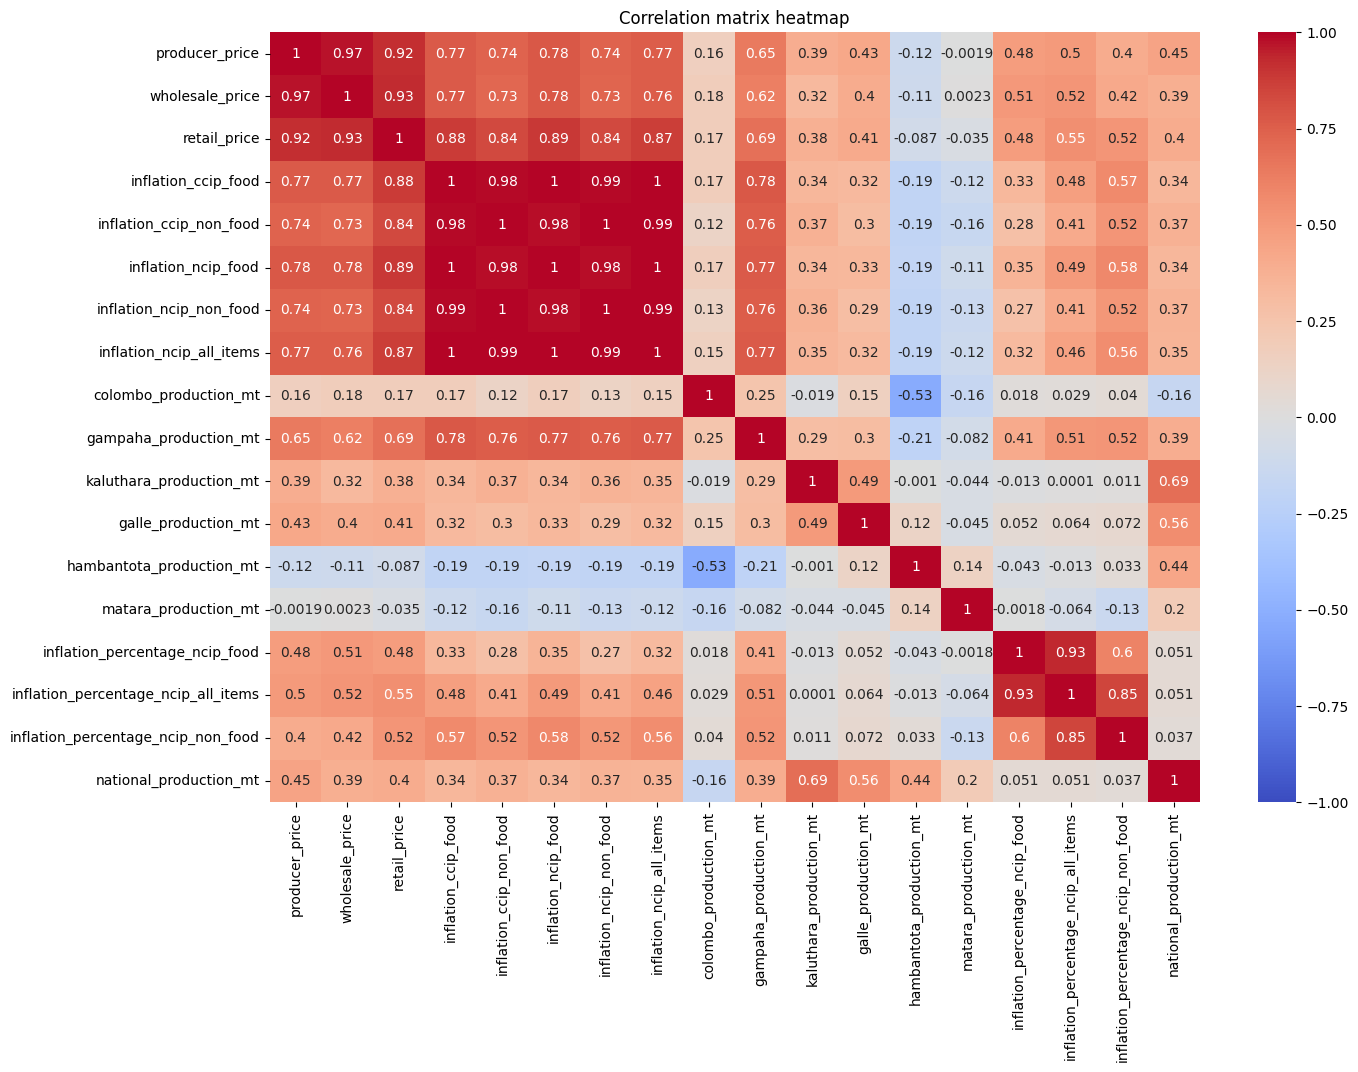

In [86]:
numeric_columns = df.select_dtypes(include=['float64', 'float64'])
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation matrix heatmap")
plt.show()

As shown in the above correlation heat map the infulence of the production in the gampaha regrion is highly and directly propotinoal to the prices. Hambantota and Matara have a very low correlation matrix with the prices. Further the rainfall affecting the relavent region also shows a very low correlation to the production.

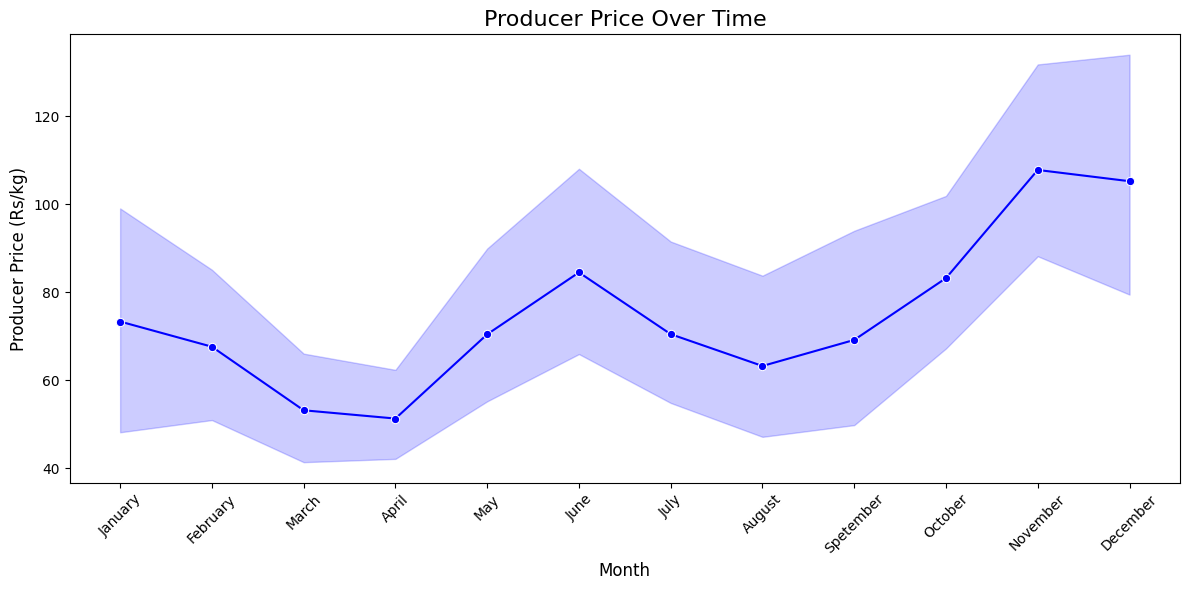

In [87]:
# line plot for producer price over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="month", y="producer_price", marker="o", color='b')

plt.title("Producer Price Over Time", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Producer Price (Rs/kg)", fontsize=12)

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


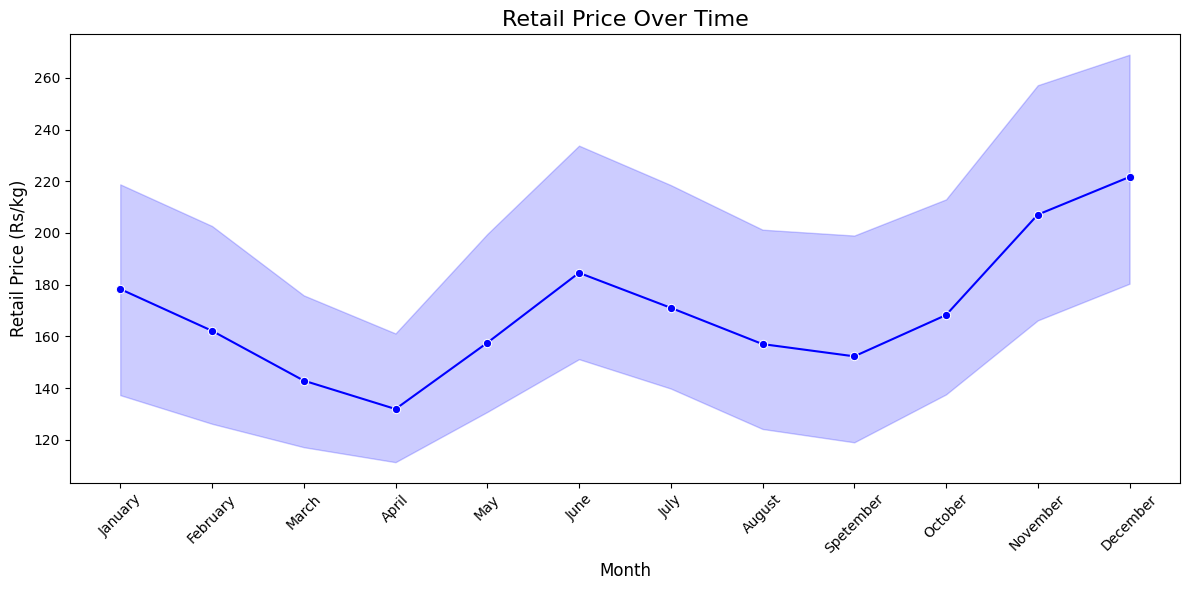

In [88]:
# line plot for relail price over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="month", y="retail_price", marker="o", color='b')


plt.title("Retail Price Over Time", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Retail Price (Rs/kg)", fontsize=12)

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


According to the line plot and the 2 seasons Maha (Spetember - March) and Yala (May - August) there is a increase in the price of long beans at the end of the year which will then again drop a considerably at the start of the new year. April has the lowest price generally

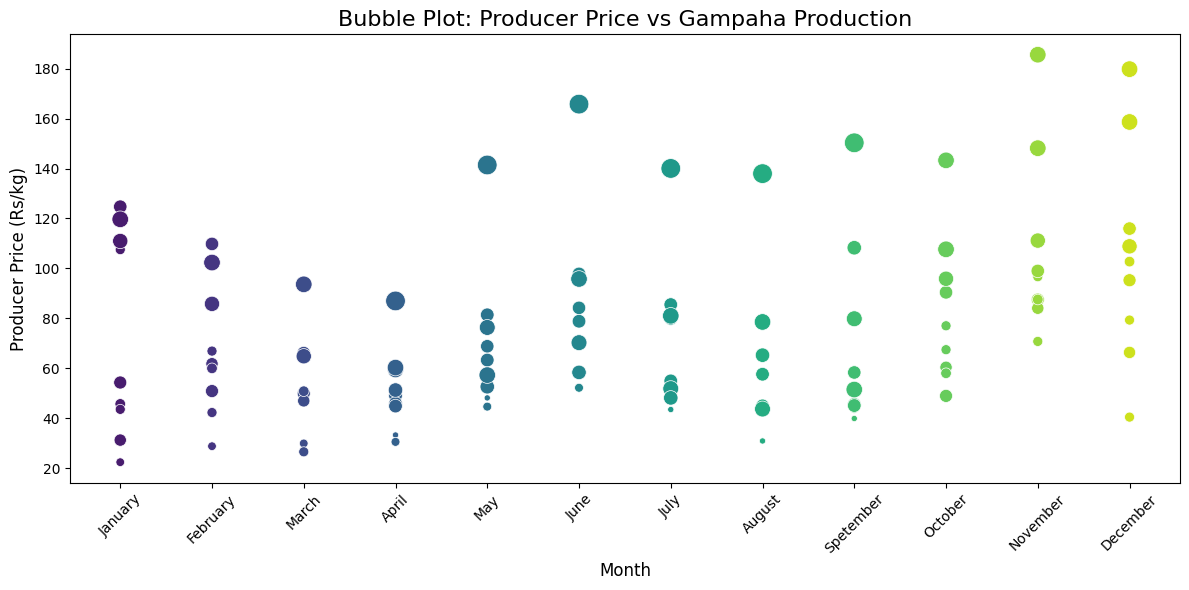

In [89]:
# Bubble plot for Producer Price vs Gampaha Production with bubble size based on Gampaha Production
plt.figure(figsize=(12, 6))

# Scatter plot with size of the bubble representing Gampaha production
sns.scatterplot(data=df, x="month", y="producer_price", size="gampaha_production_mt", hue="month", palette="viridis", sizes=(20, 200), legend=None)

# Adding titles and labels
plt.title("Bubble Plot: Producer Price vs Gampaha Production", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Producer Price (Rs/kg)", fontsize=12)

# Show the plot
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


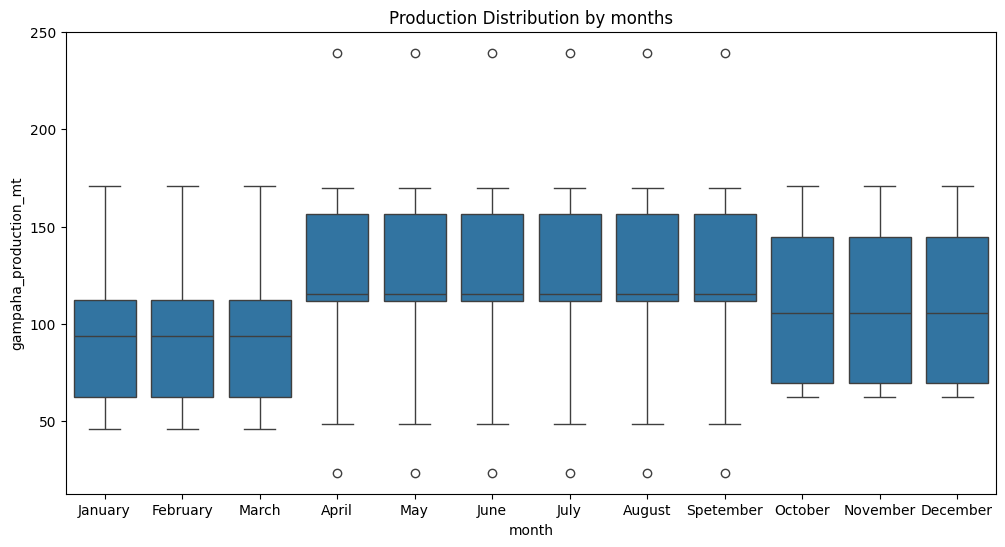

In [90]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='gampaha_production_mt', data=df)
plt.title('Production Distribution by months')
plt.show()

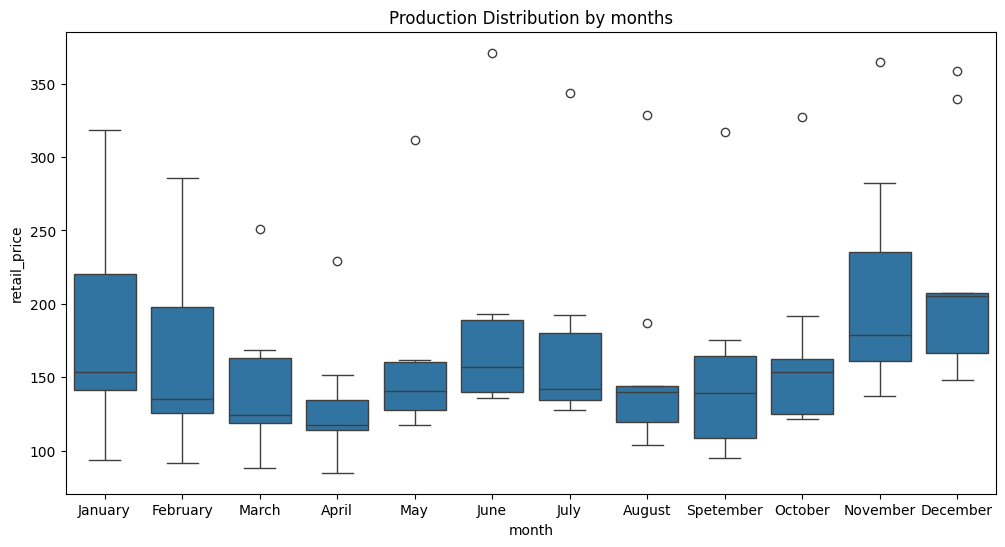

In [91]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='retail_price', data=df)
plt.title('Production Distribution by months')
plt.show()

According to the above plot the retail price of long beans

In [92]:
df.head()

,year,month,producer_price,wholesale_price,retail_price,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt,inflation_percentage_ncip_food,inflation_percentage_ncip_all_items,inflation_percentage_ncip_non_food,national_production_mt
0,2014,January,22.37,29.99,93.59,17116.88000,45789.28000,14198.75000,18921.70000,33139.11000,0.0,46.2,62.7,86.3,1365.7,27.8,0.3,3.1,5.2,4345.7
1,2014,February,28.77,30.29,91.75,17082.64624,45835.06928,14127.75625,18978.46510,33105.97089,0.0,46.2,62.7,86.3,1365.7,27.8,-0.5,-0.1,0.3,4345.7
2,2014,March,29.89,27.78,88.47,17031.39830,45880.90435,14170.13952,18997.44357,33172.18283,0.0,46.2,62.7,86.3,1365.7,27.8,0.3,0.2,0.1,4345.7
3,2014,April,33.26,36.83,85.06,17167.64949,45880.90435,14411.03189,19054.43590,33470.73248,12.8,23.5,32.0,67.2,158.0,133.3,1.7,0.9,0.3,3025.8
4,2014,May,48.12,62.59,119.51,17425.16423,45835.02344,14684.84150,19054.43590,33738.49834,12.8,23.5,32.0,67.2,158.0,133.3,1.9,0.8,0.0,3025.8


In [93]:
# Fix the typo in the 'month' column
df["month"] = df["month"].replace({"Spetember": "September"})

# Convert month names to datetime format
df["date"] = pd.to_datetime(df["year"].astype(str) + " " + df["month"], format="%Y %B")

df.head()

,year,month,producer_price,wholesale_price,retail_price,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,...,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt,inflation_percentage_ncip_food,inflation_percentage_ncip_all_items,inflation_percentage_ncip_non_food,national_production_mt,date
0,2014,January,22.37,29.99,93.59,17116.88000,45789.28000,14198.75000,18921.70000,33139.11000,...,46.2,62.7,86.3,1365.7,27.8,0.3,3.1,5.2,4345.7,2014-01-01
1,2014,February,28.77,30.29,91.75,17082.64624,45835.06928,14127.75625,18978.46510,33105.97089,...,46.2,62.7,86.3,1365.7,27.8,-0.5,-0.1,0.3,4345.7,2014-02-01
2,2014,March,29.89,27.78,88.47,17031.39830,45880.90435,14170.13952,18997.44357,33172.18283,...,46.2,62.7,86.3,1365.7,27.8,0.3,0.2,0.1,4345.7,2014-03-01
3,2014,April,33.26,36.83,85.06,17167.64949,45880.90435,14411.03189,19054.43590,33470.73248,...,23.5,32.0,67.2,158.0,133.3,1.7,0.9,0.3,3025.8,2014-04-01
4,2014,May,48.12,62.59,119.51,17425.16423,45835.02344,14684.84150,19054.43590,33738.49834,...,23.5,32.0,67.2,158.0,133.3,1.9,0.8,0.0,3025.8,2014-05-01


In [94]:
for price_type in ["producer_price", "wholesale_price", "retail_price"]:
    df[f"{price_type}_diff"] = df[price_type].diff()  # Absolute difference
    df[f"{price_type}_pct_change"] = df[price_type].pct_change() * 100  # Percentage change

# Display the dataset with the new columns
print(df[["year", "month", "producer_price", "producer_price_diff", "producer_price_pct_change",
          "wholesale_price", "wholesale_price_diff", "wholesale_price_pct_change",
          "retail_price", "retail_price_diff", "retail_price_pct_change"]])

     year      month  producer_price  producer_price_diff  \
0    2014    January           22.37                  NaN   
1    2014   February           28.77                 6.40   
2    2014      March           29.89                 1.12   
3    2014      April           33.26                 3.37   
4    2014        May           48.12                14.86   
..    ...        ...             ...                  ...   
103  2022     August          137.98                -2.07   
104  2022  September          150.33                12.35   
105  2022    October          143.30                -7.03   
106  2022   November          185.62                42.32   
107  2022   December          158.67               -26.95   

     producer_price_pct_change  wholesale_price  wholesale_price_diff  \
0                          NaN            29.99                   NaN   
1                    28.609745            30.29                  0.30   
2                     3.892944            27.78 

In [95]:
seasonal_change = []

months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

for month in months:
    month_df = df["retail_price_pct_change"][df["month"] == month]

    seasonal_change.append(month_df.sum()/len(month_df))

print(seasonal_change)

[-6.890755448382617, -7.073629085956141, -10.407948275233286, -6.327509534933283, 18.855275044281115, 17.236114505625544, -7.192504534356376, -8.424024967671738, -2.976162827222458, 12.822517843681098, 24.770460656901246, 9.103565751482812]


In [96]:
df.head()

,year,month,producer_price,wholesale_price,retail_price,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,inflation_ncip_non_food,inflation_ncip_all_items,...,inflation_percentage_ncip_all_items,inflation_percentage_ncip_non_food,national_production_mt,date,producer_price_diff,producer_price_pct_change,wholesale_price_diff,wholesale_price_pct_change,retail_price_diff,retail_price_pct_change
0,2014,January,22.37,29.99,93.59,17116.88000,45789.28000,14198.75000,18921.70000,33139.11000,...,3.1,5.2,4345.7,2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,February,28.77,30.29,91.75,17082.64624,45835.06928,14127.75625,18978.46510,33105.97089,...,-0.1,0.3,4345.7,2014-02-01,6.40,28.609745,0.30,1.000333,-1.84,-1.966022
2,2014,March,29.89,27.78,88.47,17031.39830,45880.90435,14170.13952,18997.44357,33172.18283,...,0.2,0.1,4345.7,2014-03-01,1.12,3.892944,-2.51,-8.286563,-3.28,-3.574932
3,2014,April,33.26,36.83,85.06,17167.64949,45880.90435,14411.03189,19054.43590,33470.73248,...,0.9,0.3,3025.8,2014-04-01,3.37,11.274674,9.05,32.577394,-3.41,-3.854414
4,2014,May,48.12,62.59,119.51,17425.16423,45835.02344,14684.84150,19054.43590,33738.49834,...,0.8,0.0,3025.8,2014-05-01,14.86,44.678292,25.76,69.942981,34.45,40.500823


In [97]:
df["estimated_retail_price"] = df["retail_price"].shift(1) * (1 + df["inflation_percentage_ncip_food"] / 100)

# Display relevant columns
print(df[["year", "month", "retail_price", "inflation_percentage_ncip_food", "estimated_retail_price"]])

     year      month  retail_price  inflation_percentage_ncip_food  \
0    2014    January         93.59                             0.3   
1    2014   February         91.75                            -0.5   
2    2014      March         88.47                             0.3   
3    2014      April         85.06                             1.7   
4    2014        May        119.51                             1.9   
..    ...        ...           ...                             ...   
103  2022     August        328.88                             1.7   
104  2022  September        317.28                             0.7   
105  2022    October        327.54                            -0.8   
106  2022   November        364.73                            -1.0   
107  2022   December        358.84                            -0.4   

     estimated_retail_price  
0                       NaN  
1                  93.12205  
2                  92.02525  
3                  89.97399  
4        

In [98]:
df.columns

Index(['year', 'month', 'producer_price', 'wholesale_price', 'retail_price',
       'inflation_ccip_food', 'inflation_ccip_non_food', 'inflation_ncip_food',
       'inflation_ncip_non_food', 'inflation_ncip_all_items',
       'colombo_production_mt', 'gampaha_production_mt',
       'kaluthara_production_mt', 'galle_production_mt',
       'hambantota_production_mt', 'matara_production_mt',
       'inflation_percentage_ncip_food', 'inflation_percentage_ncip_all_items',
       'inflation_percentage_ncip_non_food', 'national_production_mt', 'date',
       'producer_price_diff', 'producer_price_pct_change',
       'wholesale_price_diff', 'wholesale_price_pct_change',
       'retail_price_diff', 'retail_price_pct_change',
       'estimated_retail_price'],
      dtype='object')

In [99]:
df.drop(["inflation_ccip_food", "inflation_ccip_non_food", "estimated_retail_price", "estimated_retail_price"], axis=1, inplace=True)

In [100]:
df.columns

Index(['year', 'month', 'producer_price', 'wholesale_price', 'retail_price',
       'inflation_ncip_food', 'inflation_ncip_non_food',
       'inflation_ncip_all_items', 'colombo_production_mt',
       'gampaha_production_mt', 'kaluthara_production_mt',
       'galle_production_mt', 'hambantota_production_mt',
       'matara_production_mt', 'inflation_percentage_ncip_food',
       'inflation_percentage_ncip_all_items',
       'inflation_percentage_ncip_non_food', 'national_production_mt', 'date',
       'producer_price_diff', 'producer_price_pct_change',
       'wholesale_price_diff', 'wholesale_price_pct_change',
       'retail_price_diff', 'retail_price_pct_change'],
      dtype='object')

MAE: 86.04825783230021, RMSE: 107.68939058917279


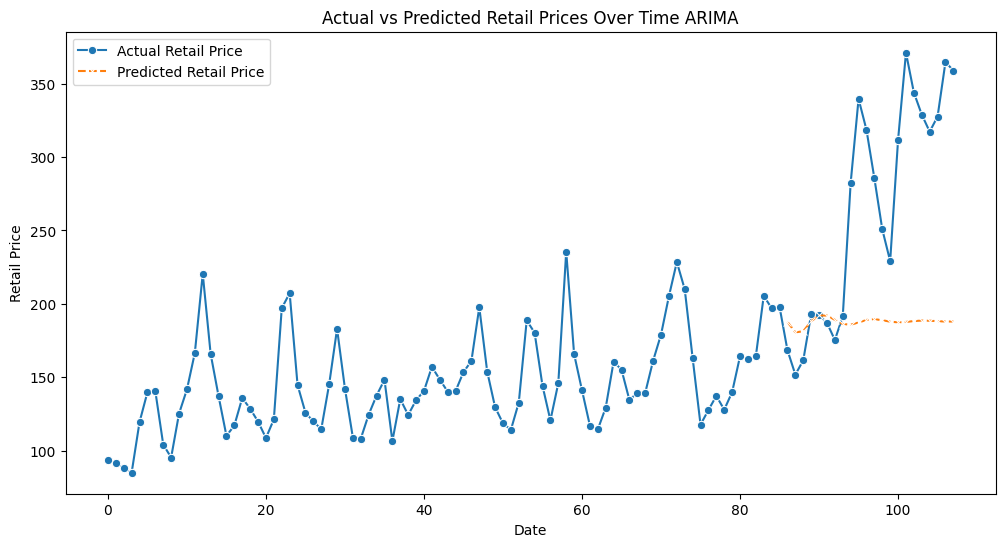

In [101]:
# Train ARIMA Model
train_size = int(len(df) * 0.8)
train, test = df["retail_price"].iloc[:train_size], df["retail_price"].iloc[train_size:]

model = ARIMA(train, order=(5,1,0))  # ARIMA order can be tuned further
model_fit = model.fit()

# Forecasting
test_pred = model_fit.forecast(steps=len(test))

df.loc[test.index, "predicted_retail_price"] = test_pred.values

# Model Evaluation
mae = mean_absolute_error(test, test_pred)
mse = mean_squared_error(test, test_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae}, RMSE: {rmse}")

# Plot actual vs predicted retail prices
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y=df["retail_price"], label="Actual Retail Price", linestyle="-", marker="o")
sns.lineplot(x=df.index, y=df["predicted_retail_price"], label="Predicted Retail Price", linestyle="--", marker="x")
plt.xlabel("Date")
plt.ylabel("Retail Price")
plt.title("Actual vs Predicted Retail Prices Over Time ARIMA")
plt.legend()
plt.show()

In [102]:
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)  # R-squared score

print("For the ARIMA Model")

# Print results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared Score (R²): {r2}")

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Accuracy in percentage
accuracy = 100 - mape

# Print accuracy
print(f"Model Accuracy: {accuracy:.2f}%")

For the ARIMA Model
Mean Absolute Error (MAE): 10616.372373511907
Mean Squared Error (MSE): 181371795.4478476
Root Mean Squared Error (RMSE): 13467.434627569113
R-squared Score (R²): 0.5857869974723573
Model Accuracy: 78.32%


In [113]:
df.columns

Index(['year', 'month', 'producer_price', 'wholesale_price', 'retail_price',
       'inflation_ncip_food', 'inflation_ncip_non_food',
       'inflation_ncip_all_items', 'colombo_production_mt',
       'gampaha_production_mt', 'kaluthara_production_mt',
       'galle_production_mt', 'hambantota_production_mt',
       'matara_production_mt', 'inflation_percentage_ncip_food',
       'inflation_percentage_ncip_all_items',
       'inflation_percentage_ncip_non_food', 'national_production_mt', 'date',
       'producer_price_diff', 'producer_price_pct_change',
       'wholesale_price_diff', 'wholesale_price_pct_change',
       'retail_price_diff', 'retail_price_pct_change',
       'predicted_retail_price'],
      dtype='object')

In [114]:
df.drop(['colombo_production_mt',
       'gampaha_production_mt', 'kaluthara_production_mt',
       'galle_production_mt', 'hambantota_production_mt',
       'matara_production_mt',], axis=1, inplace=True)

In [115]:
df.columns

Index(['year', 'month', 'producer_price', 'wholesale_price', 'retail_price',
       'inflation_ncip_food', 'inflation_ncip_non_food',
       'inflation_ncip_all_items', 'inflation_percentage_ncip_food',
       'inflation_percentage_ncip_all_items',
       'inflation_percentage_ncip_non_food', 'national_production_mt', 'date',
       'producer_price_diff', 'producer_price_pct_change',
       'wholesale_price_diff', 'wholesale_price_pct_change',
       'retail_price_diff', 'retail_price_pct_change',
       'predicted_retail_price'],
      dtype='object')

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.1549 - val_loss: 0.1315
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1061 - val_loss: 0.0895
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0560 - val_loss: 0.0537
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0307 - val_loss: 0.0376
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0279 - val_loss: 0.0377
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0324 - val_loss: 0.0347
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0300 - val_loss: 0.0371
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0243 - val_loss: 0.0395
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0205 - val_loss: 0.0352
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0219 - val_loss: 0.0313
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0253 - val_loss: 0.0300
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0229 - val_loss: 0.0304
Epoch 13/50


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
MAE: 36.62925502232143, RMSE: 47.66479776030396


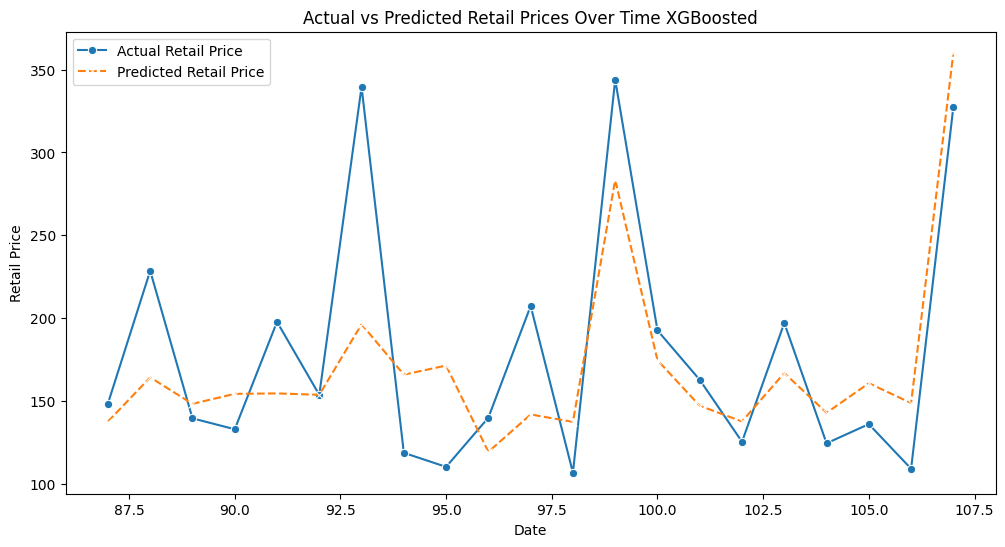

In [116]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[["retail_price"]])

X, y = [], []
look_back = 5  # Number of past observations to use
for i in range(look_back, len(df_scaled)):
    X.append(df_scaled[i - look_back:i, 0])
    y.append(df_scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build XGBoosted Neural Network Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train Model
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Predictions
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae}, RMSE: {rmse}")

# Plot actual vs predicted retail prices
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index[-len(y_test):], y=y_test.flatten(), label="Actual Retail Price", linestyle="-", marker="o")
sns.lineplot(x=df.index[-len(y_test):], y=y_pred.flatten(), label="Predicted Retail Price", linestyle="--", marker="x")
plt.xlabel("Date")
plt.ylabel("Retail Price")
plt.title("Actual vs Predicted Retail Prices Over Time XGBoosted")
plt.legend()
plt.show()

In [117]:
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)  # R-squared score

# Print results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared Score (R²): {r2}")

Mean Absolute Error (MAE): 10474.502023809526
Mean Squared Error (MSE): 185783049.8346664
Root Mean Squared Error (RMSE): 13630.225597350412
R-squared Score (R²): 0.5757126696532733


In [118]:
# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Accuracy in percentage
accuracy = 100 - mape

# Print accuracy
print(f"Model Accuracy: {accuracy:.2f}%")


Model Accuracy: 79.40%


              year  producer_price  wholesale_price  retail_price  \
count   108.000000      108.000000       108.000000    108.000000   
mean   2018.000000       74.957674        95.296690    169.542315   
min    2014.000000       22.370000        27.780000     85.060000   
25%    2016.000000       48.975000        61.435000    127.312500   
50%    2018.000000       65.235000        82.280000    145.675000   
75%    2020.000000       95.395000       120.155000    191.760000   
max    2022.000000      185.620000       244.250000    371.020000   
std       2.594026       35.168081        49.383194     66.424212   

       inflation_ncip_food  inflation_ncip_non_food  inflation_ncip_all_items  \
count           108.000000               108.000000                108.000000   
mean          20021.720674             23388.695900              43344.563976   
min           14127.756250             18844.597440              33105.970890   
25%           16133.027595             20116.328670   

<ipython-input-119-b723271b1c94>:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')  # Forward fill missing values


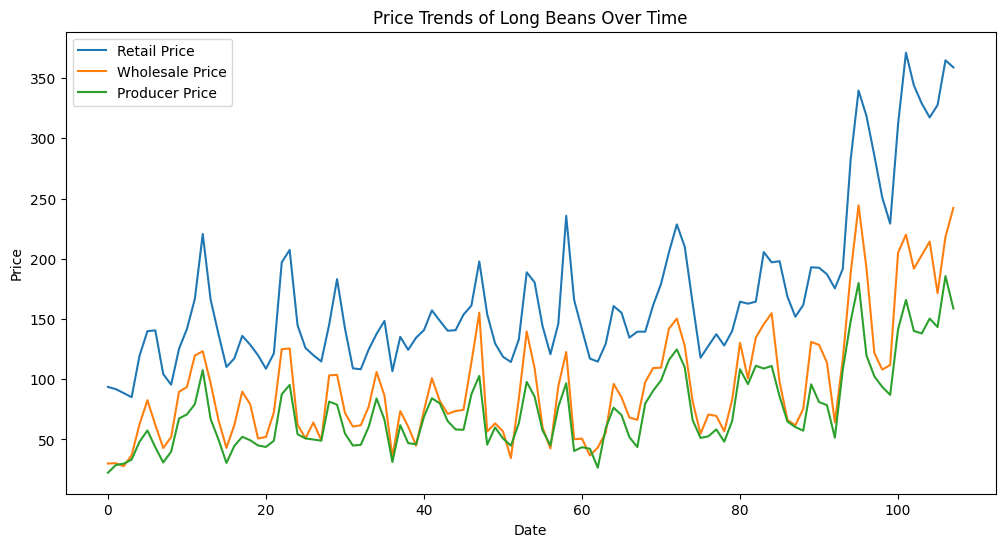

MAE: 21.94125238095238
MSE: 787.7377260033337
RMSE: 28.066665744319074
R-squared Score (R²): 0.8528886444581434
Model Accuracy: 87.35%


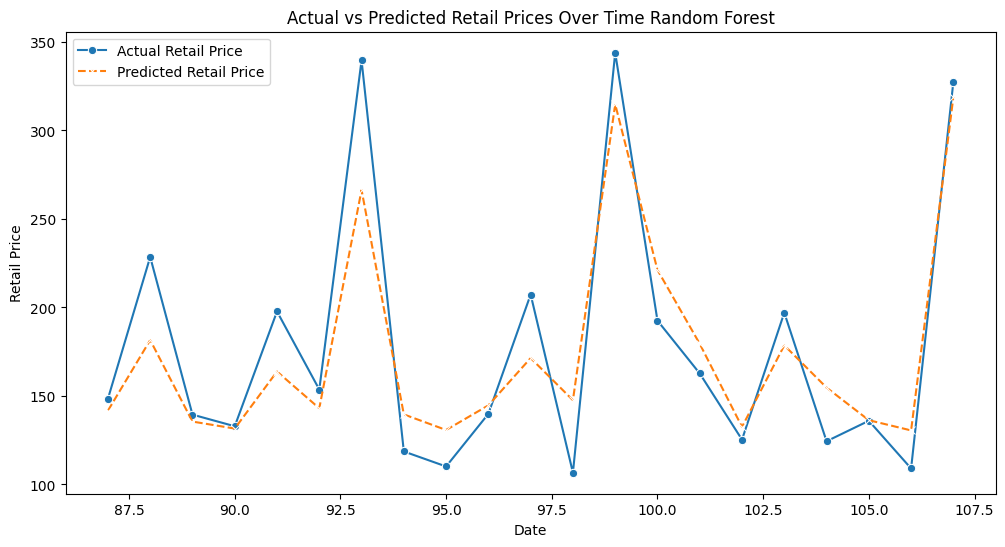

In [119]:
df = df.sort_values(by="date")

# Descriptive statistics
print(df.describe())

# Handle missing values
df = df.fillna(method='ffill')  # Forward fill missing values

# Data Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y=df["retail_price"], label="Retail Price")
sns.lineplot(x=df.index, y=df["wholesale_price"], label="Wholesale Price")
sns.lineplot(x=df.index, y=df["producer_price"], label="Producer Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Price Trends of Long Beans Over Time")
plt.legend()
plt.show()

# Prepare Data for Random Forest
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[["retail_price"]])

X, y = [], []
look_back = 5  # Number of past observations to use
for i in range(look_back, len(df_scaled)):
    X.append(df_scaled[i - look_back:i, 0])
    y.append(df_scaled[i, 0])
X, y = np.array(X), np.array(y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)  # R-squared score

# Accuracy Calculation
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R-squared Score (R²): {r2}")
print(f"Model Accuracy: {accuracy:.2f}%")

# Plot actual vs predicted retail prices
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index[-len(y_test):], y=y_test.flatten(), label="Actual Retail Price", linestyle="-", marker="o")
sns.lineplot(x=df.index[-len(y_test):], y=y_pred.flatten(), label="Predicted Retail Price", linestyle="--", marker="x")
plt.xlabel("Date")
plt.ylabel("Retail Price")
plt.title("Actual vs Predicted Retail Prices Over Time Random Forest")
plt.legend()
plt.show()


In [107]:
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)  # R-squared score

# Print results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared Score (R²): {r2}")

Mean Absolute Error (MAE): 6274.320530857144
Mean Squared Error (MSE): 64415772.85737809
Root Mean Squared Error (RMSE): 8025.943736245482
R-squared Score (R²): 0.8528886444581434


In [120]:
# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Accuracy in percentage
accuracy = 100 - mape

# Print accuracy
print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 87.35%


In [110]:
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)  # R-squared score

# Print results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared Score (R²): {r2}")

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Accuracy in percentage
accuracy = 100 - mape

# Print accuracy
print(f"Model Accuracy: {accuracy:.2f}%")

Mean Absolute Error (MAE): 1794204.6990039086
Mean Squared Error (MSE): 5267478826824.358
Root Mean Squared Error (RMSE): 2295098.8708167584
R-squared Score (R²): 0.8528886444581433
Model Accuracy: 87.37%


In [121]:
df.columns

Index(['year', 'month', 'producer_price', 'wholesale_price', 'retail_price',
       'inflation_ncip_food', 'inflation_ncip_non_food',
       'inflation_ncip_all_items', 'inflation_percentage_ncip_food',
       'inflation_percentage_ncip_all_items',
       'inflation_percentage_ncip_non_food', 'national_production_mt', 'date',
       'producer_price_diff', 'producer_price_pct_change',
       'wholesale_price_diff', 'wholesale_price_pct_change',
       'retail_price_diff', 'retail_price_pct_change',
       'predicted_retail_price'],
      dtype='object')